# Exploratieve analyse - Aanwezigheid Toegepaste Informatica

Verkennende analyse van de aanwezigheid (op basis van wifi-registraties) voor **alle jaren (1e, 2e, 3e) van Toegepaste Informatica**, over het volledige schooljaar 2025-2026 (semester 1 + semester 2).

We beperken ons tot deze richting omdat enkel hiervoor volledige wifi- en studentendata beschikbaar is (via de SharePoint-levering); andere richtingen hebben enkel data voor een testvenster van 3 weken in september.

In [1]:
import pandas as pd
import numpy as np
import sqlalchemy as sa
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## Data ophalen

Verbinding met het lokale DWH (`DEP2`), enkel Toegepaste Informatica, enkel binnen het wifi-dekkingsvenster (25/09/2025 - 29/05/2026) zodat een `0`-aanwezigheid ook echt een gemeten lage aanwezigheid is, en geen ontbrekende data.

In [2]:
server = "localhost\\MSSQLSERVER2019"
database = "DEP2"
driver = "ODBC Driver 17 for SQL Server"

engine = sa.create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver={driver}&trusted_connection=yes&TrustServerCertificate=yes"
)

query = """SELECT
    FactLecture.LectureID, FactLecture.DateKey, FactLecture.UserCount, FactLecture.TotalStudents,
    FactLecture.AttendanceRate, FactLecture.OccupancyRate,
    DimDate.FullDate, DimDate.NameDayDutch, DimDate.Weekday, DimDate.NumberSemester, DimDate.Month, DimDate.Season,
    dt_from.Hour AS FromHour,
    DimClass.ClassName, DimClass.ClassProgramStage,
    DimSubgroup.SubgroupCode, DimSubgroup.ProgramName,
    DimActivity.CanonicalActivity, DimActivity.ActivityDomain, DimActivity.ActivityGroup
FROM FactLecture
JOIN DimDate ON FactLecture.DateKey = DimDate.DateKey
JOIN DimTime dt_from ON FactLecture.FromTimeKey = dt_from.TimeKey
JOIN DimClass ON FactLecture.ClassKey = DimClass.ClassKey
JOIN DimSubgroup ON FactLecture.SubgroupKey = DimSubgroup.SubgroupKey
JOIN DimActivity ON FactLecture.ActivityKey = DimActivity.ActivityKey
WHERE DimSubgroup.ProgramName LIKE 'PBA-TIN%'
  AND FactLecture.AttendanceRate IS NOT NULL
  AND FactLecture.DateKey BETWEEN 20250925 AND 20260529"""

df = pd.read_sql(query, engine)
df["FullDate"] = pd.to_datetime(df["FullDate"])
df.shape

(5460, 20)

## Overzicht van de dataset

In [3]:
df.head()

,LectureID,DateKey,UserCount,TotalStudents,AttendanceRate,OccupancyRate,FullDate,NameDayDutch,Weekday,NumberSemester,Month,Season,FromHour,ClassName,ClassProgramStage,SubgroupCode,ProgramName,CanonicalActivity,ActivityDomain,ActivityGroup
0,381437,20250929,19,35,0.542857,0.500000,2025-09-29,Maandag,1,1,9,Fall,8,Object-oriented Software Development I,1.0,PBA-TIN-TI/1A,PBA-TIN-TI,Activerend hoorcollege,Course,Lecture
1,381438,20251006,17,35,0.485714,0.404762,2025-10-06,Maandag,1,1,10,Fall,8,Object-oriented Software Development I,1.0,PBA-TIN-TI/1A,PBA-TIN-TI,Activerend hoorcollege,Course,Lecture
2,381439,20251013,0,35,0.000000,0.000000,2025-10-13,Maandag,1,1,10,Fall,8,Object-oriented Software Development I,1.0,PBA-TIN-TI/1A,PBA-TIN-TI,Activerend hoorcollege,Course,Lecture
3,381440,20251020,18,35,0.514286,0.473684,2025-10-20,Maandag,1,1,10,Fall,8,Object-oriented Software Development I,1.0,PBA-TIN-TI/1A,PBA-TIN-TI,Activerend hoorcollege,Course,Lecture
4,381441,20251027,18,35,0.514286,0.450000,2025-10-27,Maandag,1,1,10,Fall,8,Object-oriented Software Development I,1.0,PBA-TIN-TI/1A,PBA-TIN-TI,Activerend hoorcollege,Course,Lecture


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5460 entries, 0 to 5459
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype        
---  ------             --------------  -----        
 0   LectureID          5460 non-null   int64        
 1   DateKey            5460 non-null   int64        
 2   UserCount          5460 non-null   int64        
 3   TotalStudents      5460 non-null   int64        
 4   AttendanceRate     5460 non-null   float64      
 5   OccupancyRate      5460 non-null   float64      
 6   FullDate           5460 non-null   datetime64[s]
 7   NameDayDutch       5460 non-null   str          
 8   Weekday            5460 non-null   int64        
 9   NumberSemester     5460 non-null   int64        
 10  Month              5460 non-null   int64        
 11  Season             5460 non-null   str          
 12  FromHour           5460 non-null   int64        
 13  ClassName          5460 non-null   str          
 14  ClassProgramStage  5448 non-null   

## Centrale tendens van de aanwezigheid

Gemiddelde en mediaan liggen bewust ver uiteen te verwachten: aanwezigheid is typisch scheef verdeeld (veel lessen met lage opkomst, een kleinere groep met hoge opkomst).

In [5]:
mean_attendance = df["AttendanceRate"].mean()
median_attendance = df["AttendanceRate"].median()
std_attendance = df["AttendanceRate"].std()

print(f"Gemiddelde aanwezigheid: {mean_attendance:.1%}")
print(f"Mediaan aanwezigheid:    {median_attendance:.1%}")
print(f"Standaardafwijking:      {std_attendance:.1%}")

df["AttendanceRate"].describe()

Gemiddelde aanwezigheid: 28.6%
Mediaan aanwezigheid:    25.0%
Standaardafwijking:      25.4%


count    5460.000000
mean        0.285611
std         0.253705
min         0.000000
25%         0.037037
50%         0.250000
75%         0.473684
max         1.666667
Name: AttendanceRate, dtype: float64

## Verdeling van de aanwezigheid

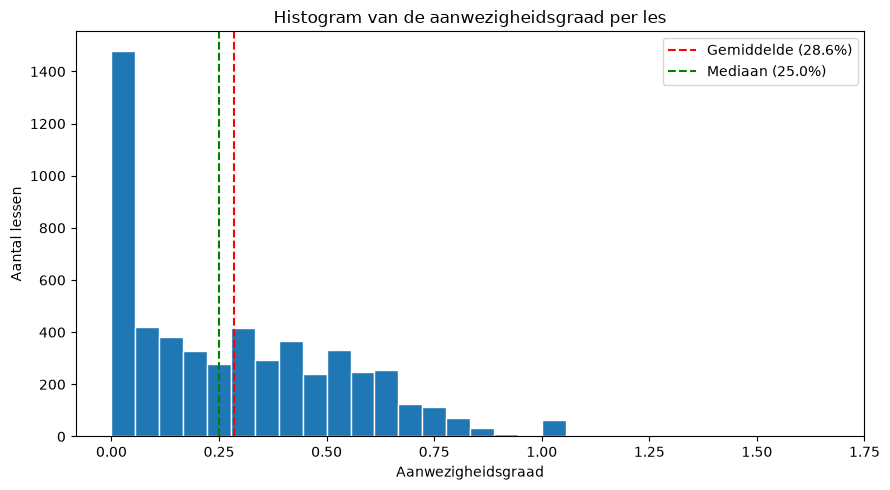

In [6]:
plt.figure(figsize=(9, 5))
plt.hist(df["AttendanceRate"], bins=30, color="tab:blue", edgecolor="white")
plt.axvline(mean_attendance, color="red", linestyle="--", label=f"Gemiddelde ({mean_attendance:.1%})")
plt.axvline(median_attendance, color="green", linestyle="--", label=f"Mediaan ({median_attendance:.1%})")
plt.xlabel("Aanwezigheidsgraad")
plt.ylabel("Aantal lessen")
plt.title("Histogram van de aanwezigheidsgraad per les")
plt.legend()
plt.tight_layout()
plt.show()

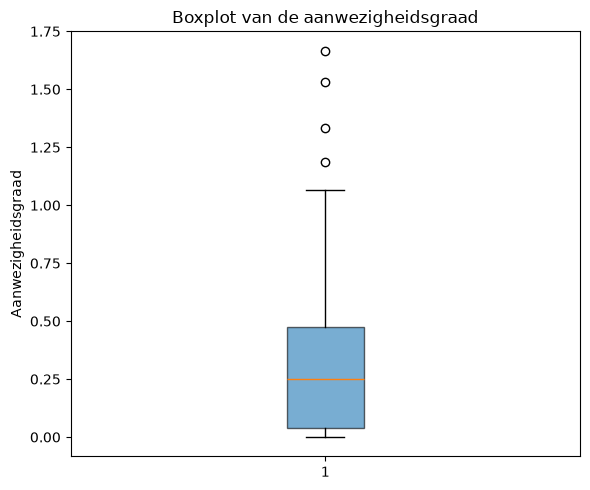

In [7]:
plt.figure(figsize=(6, 5))
plt.boxplot(df["AttendanceRate"], patch_artist=True,
            boxprops=dict(facecolor="tab:blue", alpha=0.6))
plt.ylabel("Aanwezigheidsgraad")
plt.title("Boxplot van de aanwezigheidsgraad")
plt.tight_layout()
plt.show()

## Lessen met erg lage of erg hoge aanwezigheid

In [8]:
low_attendance = df[df["AttendanceRate"] < 0.20]
high_attendance = df[df["AttendanceRate"] > 0.90]

print(f"Lessen met < 20% aanwezigheid: {len(low_attendance)} van {len(df)} ({len(low_attendance)/len(df):.1%})")
print(f"Lessen met > 90% aanwezigheid: {len(high_attendance)} van {len(df)} ({len(high_attendance)/len(df):.1%})")

Lessen met < 20% aanwezigheid: 2441 van 5460 (44.7%)
Lessen met > 90% aanwezigheid: 82 van 5460 (1.5%)


**Datakwaliteit-check**: `AttendanceRate` is `UserCount / TotalStudents`. Een enkele les kan hier net boven 100% uitkomen (bv. als er studenten van een andere subgroep in hetzelfde lokaal/wifi-bereik meetellen). Dit komt zelden voor - hieronder tellen we hoeveel.

In [9]:
over_100 = df[df["AttendanceRate"] > 1]
print(f"Lessen met > 100% aanwezigheid: {len(over_100)} van {len(df)} ({len(over_100)/len(df):.2%})")
over_100[["LectureID", "ClassName", "SubgroupCode", "UserCount", "TotalStudents", "AttendanceRate"]]

Lessen met > 100% aanwezigheid: 5 van 5460 (0.09%)


,LectureID,ClassName,SubgroupCode,UserCount,TotalStudents,AttendanceRate
84,471440,Object-oriented Software Development I,PBA-TIN-TI/1H,49,32,1.531250
184,382294,Object-oriented Software Development I,PBA-TIN-TI/1E,33,31,1.064516
200,381727,Object-oriented Software Development I,PBA-TIN-TI/1B,38,32,1.187500
3167,473783,Classic Computer Science Algorithms,PBA-TIN-TI/VT/PROG/S1,5,3,1.666667
3176,473782,Classic Computer Science Algorithms,PBA-TIN-TI/VT/PROG/S1,4,3,1.333333


## Aanwezigheid per dag van de week

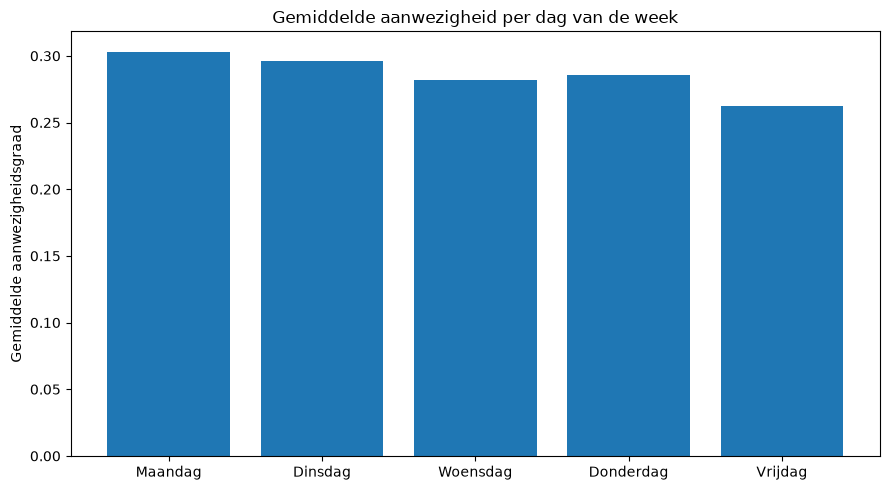

,mean,median,count
NameDayDutch,,,
Maandag,0.303220,0.261983,948.0
Dinsdag,0.295910,0.300000,1125.0
Woensdag,0.281894,0.235294,1041.0
Donderdag,0.285958,0.253571,1266.0
Vrijdag,0.262605,0.189904,1080.0


In [10]:
weekday_order = ["Maandag", "Dinsdag", "Woensdag", "Donderdag", "Vrijdag", "Zaterdag", "Zondag"]
by_weekday = df.groupby("NameDayDutch")["AttendanceRate"].agg(["mean", "median", "count"]).reindex(weekday_order).dropna(how="all")

plt.figure(figsize=(9, 5))
plt.bar(by_weekday.index, by_weekday["mean"], color="tab:blue")
plt.ylabel("Gemiddelde aanwezigheidsgraad")
plt.title("Gemiddelde aanwezigheid per dag van de week")
plt.tight_layout()
plt.show()

by_weekday

## Aanwezigheid per uur van de dag

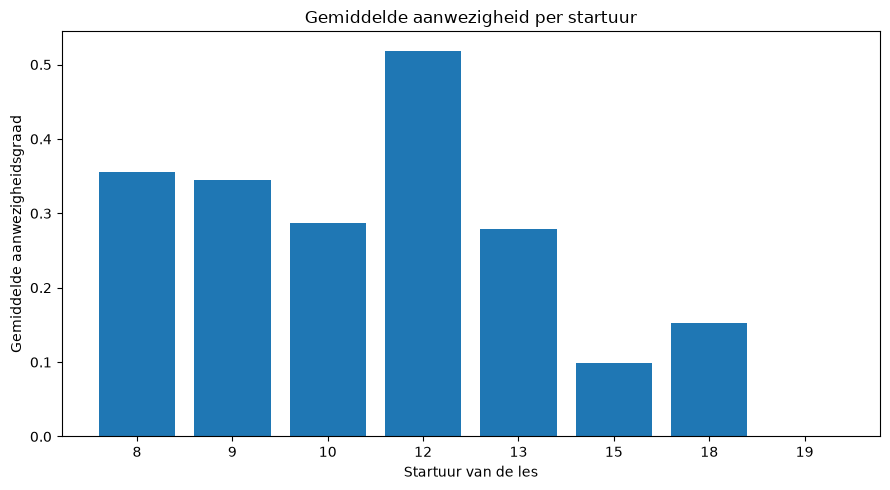

,mean,median,count
FromHour,,,
8,0.355055,0.344289,1146
9,0.344184,0.333333,714
10,0.287604,0.272727,1547
12,0.518737,0.545455,14
13,0.279143,0.236068,1400
15,0.099009,0.025978,626
18,0.152778,0.108333,12
19,0.000000,0.000000,1


In [11]:
by_hour = df.groupby("FromHour")["AttendanceRate"].agg(["mean", "median", "count"])

plt.figure(figsize=(9, 5))
plt.bar(by_hour.index.astype(str), by_hour["mean"], color="tab:blue")
plt.xlabel("Startuur van de les")
plt.ylabel("Gemiddelde aanwezigheidsgraad")
plt.title("Gemiddelde aanwezigheid per startuur")
plt.tight_layout()
plt.show()

by_hour

## Aanwezigheid per jaar (modeltraject)

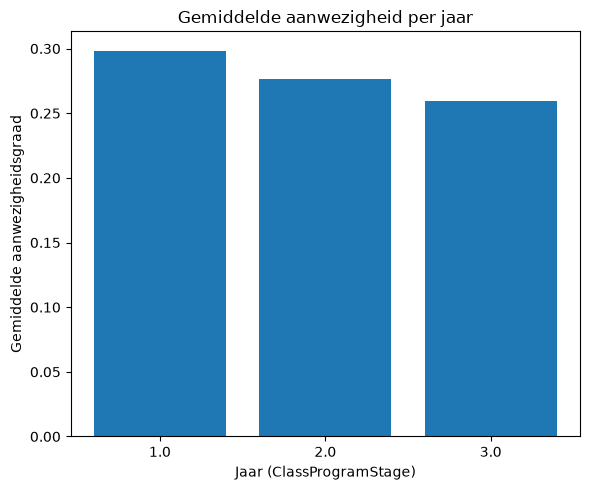

,mean,median,count
ClassProgramStage,,,
1.0,0.298433,0.272727,2858
2.0,0.276628,0.250000,1907
3.0,0.259376,0.173913,683


In [12]:
by_year = df.groupby("ClassProgramStage")["AttendanceRate"].agg(["mean", "median", "count"])

plt.figure(figsize=(6, 5))
plt.bar(by_year.index.astype(str), by_year["mean"], color="tab:blue")
plt.xlabel("Jaar (ClassProgramStage)")
plt.ylabel("Gemiddelde aanwezigheidsgraad")
plt.title("Gemiddelde aanwezigheid per jaar")
plt.tight_layout()
plt.show()

by_year

## Aanwezigheid per lesvorm

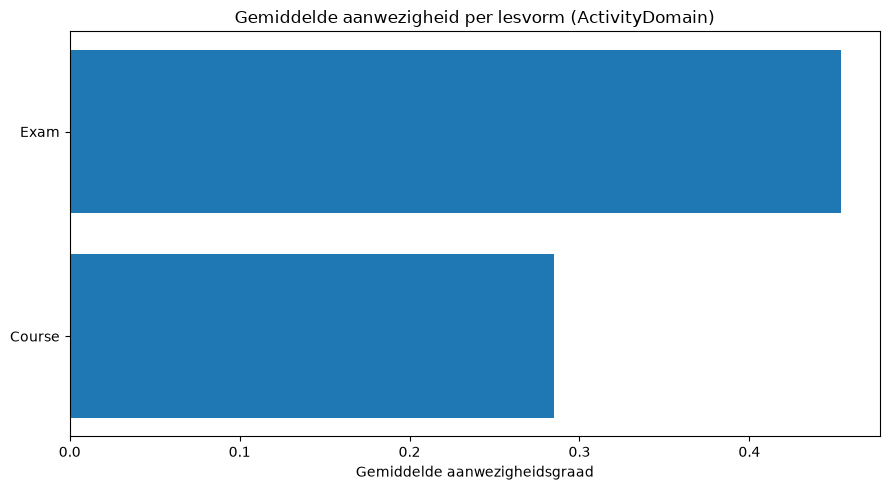

,mean,median,count
ActivityDomain,,,
Exam,0.454175,0.50,27
Course,0.284774,0.25,5433


In [13]:
by_activity = df.groupby("ActivityDomain")["AttendanceRate"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(by_activity.index[::-1], by_activity["mean"][::-1], color="tab:blue")
plt.xlabel("Gemiddelde aanwezigheidsgraad")
plt.title("Gemiddelde aanwezigheid per lesvorm (ActivityDomain)")
plt.tight_layout()
plt.show()

by_activity

## Semester 1 vs semester 2

Eerste blik op het verschil tussen de twee semesters - wordt verder uitgediept in een aparte analyse.

In [14]:
by_semester = df.groupby("NumberSemester")["AttendanceRate"].agg(["mean", "median", "std", "count"])
by_semester.index = by_semester.index.map({1: "Semester 1", 2: "Semester 2"})
by_semester

,mean,median,std,count
NumberSemester,,,,
Semester 1,0.295422,0.266667,0.260381,2417
Semester 2,0.277819,0.225806,0.248040,3043


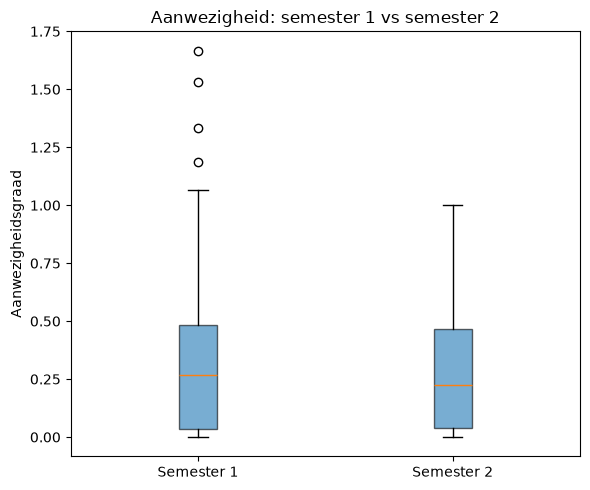

In [15]:
sem1 = df[df["NumberSemester"] == 1]["AttendanceRate"]
sem2 = df[df["NumberSemester"] == 2]["AttendanceRate"]

plt.figure(figsize=(6, 5))
plt.boxplot([sem1, sem2], tick_labels=["Semester 1", "Semester 2"], patch_artist=True,
            boxprops=dict(facecolor="tab:blue", alpha=0.6))
plt.ylabel("Aanwezigheidsgraad")
plt.title("Aanwezigheid: semester 1 vs semester 2")
plt.tight_layout()
plt.show()

## Aanwezigheid doorheen het schooljaar

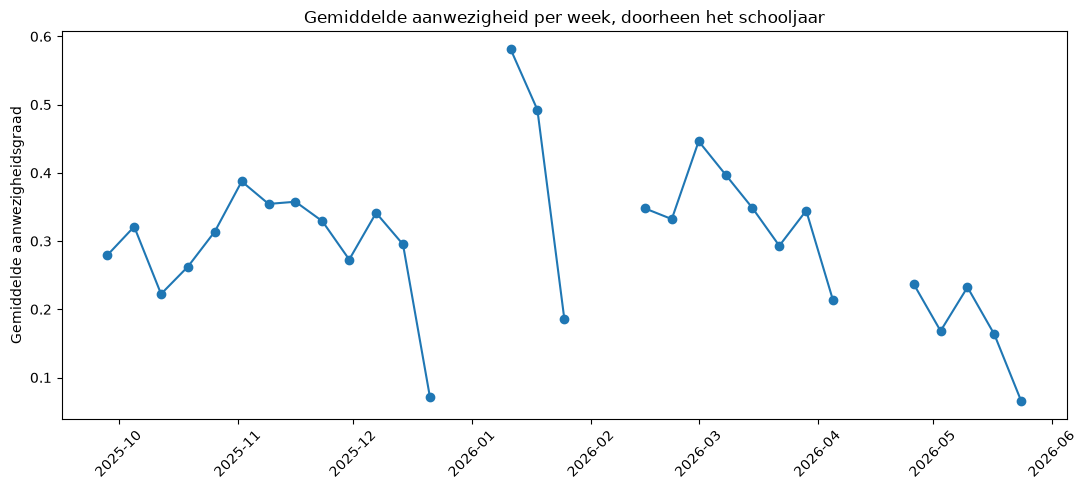

In [16]:
weekly = df.set_index("FullDate").resample("W")["AttendanceRate"].mean()

plt.figure(figsize=(11, 5))
plt.plot(weekly.index, weekly.values, marker="o", color="tab:blue")
plt.ylabel("Gemiddelde aanwezigheidsgraad")
plt.title("Gemiddelde aanwezigheid per week, doorheen het schooljaar")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()